# 步骤三遇到的问题和解释

## 为啥从结果上看，brats的数值这么低，这个数值是越低越好吗？

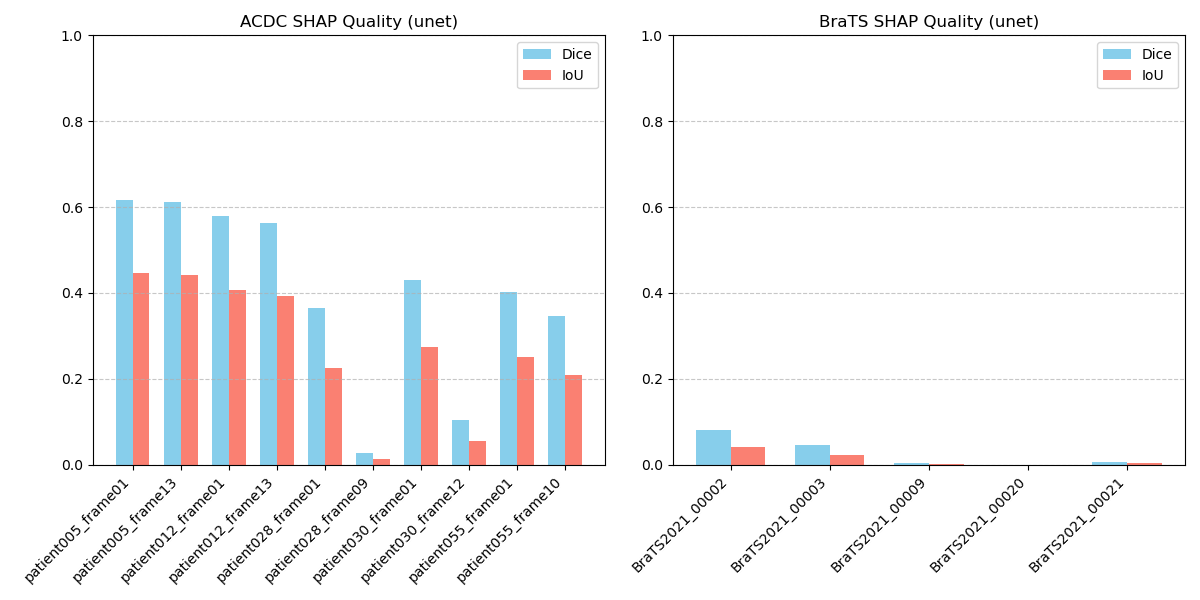

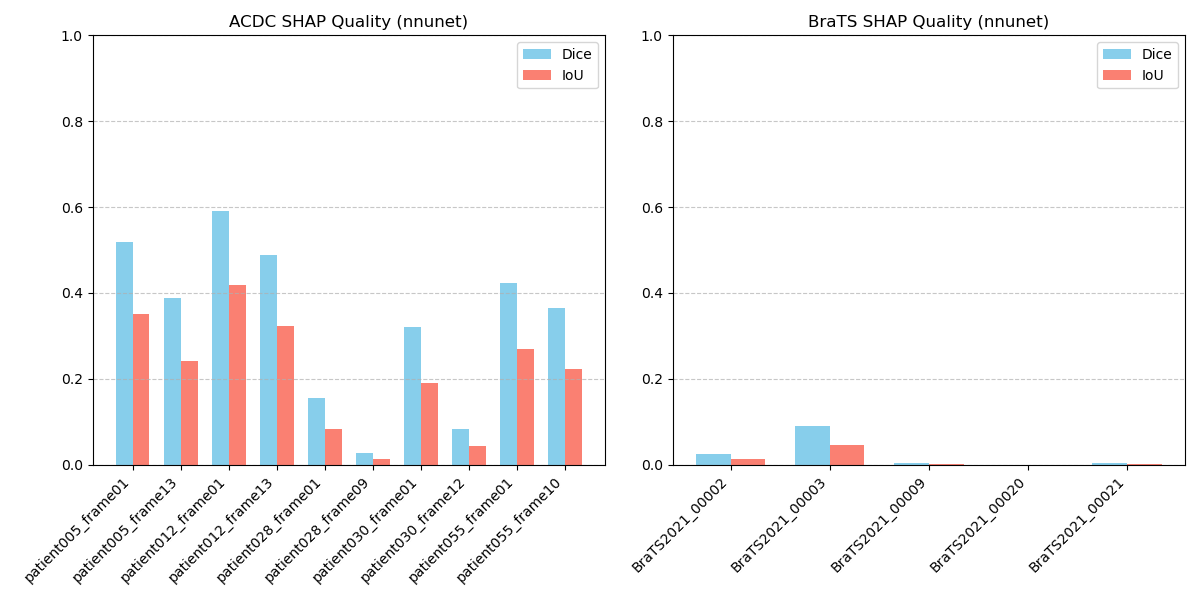

这是一个非常敏锐的观察。首先回答您的问题：__Dice 和 IoU 数值是越高越好__，而不是越低越好。

数值高代表模型“看”的地方（SHAP 贡献最高的前 10% 区域）与医生标注的“真实病灶区域”高度重合。BraTS 的数值远低于 ACDC，主要由以下几个技术原因造成：

### 1. 3D 空间的“稀疏性”问题（最主要原因）

- __ACDC (2D)__：心脏在 2D 切片中占比较大，Top 10% 的解释区域很容易覆盖到心脏的大部分。
- __BraTS (3D)__：肿瘤在整个脑部 3D 体积中的占比通&#x5E38;__&#x8FDC;小于 10%__（可能只有 1% 或更低）。当我们强制取 Top 10% 的像素作为“解释区域”时，分母会变得非常大，导致 Dice 公式 $2|A \cap B| / (|A| + |B|)$ 中的 $|B|$ 远大于 $|A|$，从而拉低了分值。

### 2. 剧烈的下采样损失

- 为了能在显存中跑通 SHAP，我们将 BraTS 从 $128 \times 128 \times 128$ 下采样到了 $32 \times 32 \times 32$。
- 这&#x79CD;__&#x36;4 倍的空间压&#x7F29;__&#x4F1A;导致肿瘤的边界变得极其模糊，很多细小的病灶特征在下采样过程中消失了，导致解释结果很难精准匹配原始的真值掩码。

### 3. 解释区域的“弥散”现象

- BraTS 有 4 个模态（T1, T1ce, T2, FLAIR）。模型在做决策时，注意力会分散在四个模态的不同位置。
- 例如，模型可能通过 T2 模态看水肿，通过 T1ce 看增强核心。当我们把这些贡献度叠加在一起时，解释区域会显得比单一的肿瘤核心（Class 3）要宽泛得多。

### 4. 模型的辅助关注点

- 模型在判断肿瘤时，往往会关注肿瘤周边&#x7684;__&#x5065;康组织边&#x754C;__&#x6216;__对称位置的脑组&#x7EC7;__&#x4F5C;为参照。这些区域对模型预测有贡献（SHAP 高分），但它们并不属于“肿瘤”本身，因此在计算 Dice 时被视为“错误”。
